In [15]:
from pathlib import Path
import sys
from time import time

# Allows the notebook to import files from the project root.
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots
from src.preprocessing import load_csv, preprocess_data
from src.interval_based_methods import (
    velocity_magnitude_method_partitioned,
    average_velocity_magnitude,
)

In [17]:
file_path = PROJECT_ROOT / "data" / "Seated_Global.csv"

df = load_csv(file_path)
data = preprocess_data(df, do_savgol=True)

In [24]:
bucket_size = 5
results = {
    "Velocity Magnitude": velocity_magnitude_method_partitioned(data, bucket_size=bucket_size)
}

Plotting

1.357758963422887


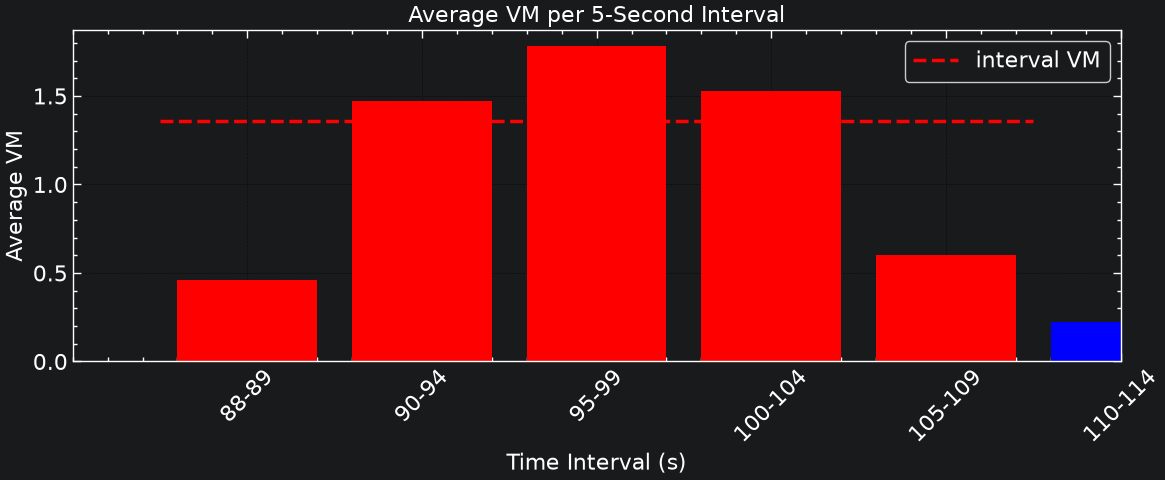

In [27]:
#------------------ VM PLOT
#padding for plot
xPad = 1

#start and end time for summation
t_1 =  min(data["time"])
t_2 = 20.0+min(data["time"])


if t_1 < min(data["time"]) or t_2 > max(data["time"]) or t_1 > t_2:
    raise ValueError("t_1 and t_2 set incorrectly. Check the following conditions:"
                      + "\n \t t_1 < min(time)"
                     + "\n \t t_2 < max(time)"
                     + "\n \t t_1 > t_2")

df_5s = results["Velocity Magnitude"]

interval_VM = average_velocity_magnitude(
    data,
    t_1,
    t_2,
)

print(interval_VM)

labels = [
    f"{int(s)}-{int(e)}"
    for s, e in zip(df_5s["start_time"], df_5s["end_time"])
]

colors = [
    "red" if (t_1 // bucket_size) <= b <= (t_2 // bucket_size) else "blue"
    for b in df_5s["bucket"]
]

target_buckets = range(int(t_1 // bucket_size), int(t_2 // bucket_size) + 1)
pos = df_5s.index[df_5s["bucket"].isin(target_buckets)].to_numpy()

pos_min = pos.min()
pos_max = pos.max()

plt.figure(figsize=(12,5))
plt.style.use(['science', 'notebook', 'grid'])
plt.bar(labels, df_5s["avg_VM"], color=colors)
plt.hlines(y=interval_VM, xmin=pos_min - .5, xmax=pos_max + .5,
           color='red', linestyle='--', linewidth=2.5, label='interval VM')
plt.legend()


xmin = pos_min - xPad
xmax = pos_max + xPad

plt.xlim(xmin, xmax)

plt.xlabel("Time Interval (s)")
plt.ylabel("Average VM")
plt.title("Average VM per 5-Second Interval")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#------------------ UW PLOT